# 08 — Tabular Q-Learning Baseline

*This notebook implements the simplest possible RL baseline — tabular Q-learning on a discretised LunarLander-v3 state space.  It answers two questions for the thesis: (1) does even a table-based agent partially solve the task, and (2) when a fault is injected, are Q-value shifts at fault onset visible in a lookup table as they are (hopefully) in deep networks?*

**Motivation.** The supervisor requested a tabular Q-learning baseline to ground the comparison against the simplest possible value-based algorithm.  If Q-value shifts at fault onset are visible in tabular Q-learning, the self-detection result is fundamental to value-based RL, not an artefact of deep function approximation.

---

## Theory

### Q-Learning (Watkins & Dayan, 1992)

The Q-learning update for a single transition $(s, a, r, s')$:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \bigl[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \bigr]$$

with $\varepsilon$-greedy policy:

$$\pi(a|s) = \begin{cases} 1 - \varepsilon + \varepsilon / |\mathcal{A}| & \text{if } a = \arg\max_a Q(s, \cdot) \\ \varepsilon / |\mathcal{A}| & \text{otherwise} \end{cases}$$

$\varepsilon$ decays linearly from 1.0 to 0.01 over 300k steps.

### State Discretisation

LunarLander-v3 has an 8-D continuous observation: $[x, y, v_x, v_y, \theta, \omega, c_L, c_R]$.  We tile each of the 6 continuous dimensions into $B = 10$ equal-width bins and the 2 contact booleans into 2 bins each, giving $10^6 \times 2^2 = 4{,}000{,}000$ states.  The Q-table is stored as a sparse dictionary to avoid allocating unvisited cells.

**Bin ranges** (clipped):

| Dim | Variable | Range | Justification |
|-----|----------|-------|---------------|
| 0 | $x$ | $[-1.5, 1.5]$ | Pad width covers landing zone |
| 1 | $y$ | $[-0.5, 2.0]$ | Below ground to above launch |
| 2 | $v_x$ | $[-3.0, 3.0]$ | Symmetric lateral velocity |
| 3 | $v_y$ | $[-3.0, 0.5]$ | Mostly negative (falling) |
| 4 | $\theta$ | $[-\pi, \pi]$ | Full rotation |
| 5 | $\omega$ | $[-5.0, 5.0]$ | Angular velocity |
| 6 | $c_L$ | $\{0, 1\}$ | Left leg contact boolean |
| 7 | $c_R$ | $\{0, 1\}$ | Right leg contact boolean |

### Comparison with Deep-RL Baselines

| Property | Q-learning | PPO | SAC |
|----------|-----------|-----|-----|
| Function approx. | None (table) | MLP 64×64 | MLP 400×300 |
| Action space | Discrete(4) | Discrete(4) | Continuous Box(2) |
| Update rule | Off-policy, single-step TD | On-policy, PPO clip | Off-policy, soft Bellman |
| Memory | Sparse dict (~MB) | Network params (~50KB) | Network + replay (~100MB) |
| State representation | Discretised bins | Raw continuous | Raw continuous |

---

## 8.1 Imports and setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../py'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

from src.q_learning import (
    QLearningAgent, StateDiscretizer, train_q_learning,
    evaluate_with_signals, _evaluate_agent,
)
from src.utils.seeding import set_global_seed
from src.utils.logging_utils import dump_json

sns.set_theme(style='whitegrid', context='paper', font_scale=1.2)
%matplotlib inline

RUNS_ROOT = Path('../py/runs')
LOGS_ROOT = Path('../py/logs')
LOGS_ROOT.mkdir(exist_ok=True)

print('Setup complete.')

Setup complete.


## 8.2 Train Q-learning (5 seeds x 500k steps)

*We train 5 seeds (0-4) for parity with the PPO and SAC baselines.  Each run takes ~2-3 min on M4.*

**Expected outcome.**  Q-learning will **not** solve LunarLander: the coarse 10-bin discretisation loses too much information and the agent visits under 1 % of the resulting state space.  Returns are expected to land far below PPO (+256), SAC (+262) and PPO+DR (+148).  This is by design -- the tabular baseline establishes a *representational floor*, not a competitive entry.

> **Observed vs anticipated.**  An earlier version of this cell anticipated returns in the +50 to +150 band.  The realised aggregate is **-63.87** (cross-seed sd 19.34; per-seed -44.23 to -90.53), roughly 100 points below that band.  The discrepancy is explained by state coverage: at 500 k steps the agent reaches **<1 %** of the ~4 M discretised states, so the greedy policy is acting on an all-zero row -- i.e. uniformly at random -- for the large majority of states it encounters at evaluation time.  The anticipated band implicitly assumed coverage sufficient for the greedy policy to be defined along a full descent trajectory, which uniform binning at this budget does not deliver.  The revised expectation is recorded here rather than silently corrected, because the *size* of the gap is itself the evidence for the aliasing argument developed in section 8.7.


In [2]:
import gymnasium as gym
import time

SEEDS = [0, 1, 2, 3, 4]
TOTAL_TIMESTEPS = 500_000
ENV_ID = 'LunarLander-v3'

# Discretiser config (matches configs/q_learning_lunarlander.yaml)
discretizer = StateDiscretizer(
    n_bins=10,
    obs_ranges=[
        (-1.5, 1.5), (-0.5, 2.0), (-3.0, 3.0),
        (-3.0, 0.5), (-np.pi, np.pi), (-5.0, 5.0),
    ],
)

seed_results = {}

for seed in SEEDS:
    print(f'\n{"="*60}')
    print(f'Training Q-learning seed={seed}')
    print(f'{"="*60}')
    set_global_seed(seed)

    env = gym.make(ENV_ID)
    env.reset(seed=seed)
    env.action_space.seed(seed)

    eval_env = gym.make(ENV_ID)
    eval_env.reset(seed=seed + 7777)

    agent = QLearningAgent(
        n_actions=4,
        discretizer=discretizer,
        alpha=0.1,
        gamma=0.999,
        epsilon_start=1.0,
        epsilon_end=0.01,
        epsilon_decay_steps=300_000,
        seed=seed,
    )

    t0 = time.time()
    history = train_q_learning(
        agent=agent,
        env=env,
        total_timesteps=TOTAL_TIMESTEPS,
        eval_freq=10_000,
        n_eval_episodes=20,
        eval_env=eval_env,
        verbose=True,
    )
    elapsed = time.time() - t0

    # Final eval (50 episodes, greedy)
    mean_r, std_r = _evaluate_agent(agent, eval_env, 50)

    seed_results[seed] = {
        'agent': agent,
        'history': history,
        'mean_return': mean_r,
        'std_return': std_r,
        'wallclock': elapsed,
        'n_visited': agent.n_visited_states,
    }

    # Save agent
    run_dir = RUNS_ROOT / f'q_learning__LunarLander-v3__seed{seed}'
    run_dir.mkdir(parents=True, exist_ok=True)
    agent.save(run_dir / 'q_table_final.npz')
    dump_json(run_dir / 'final_summary.json', {
        'final_eval_mean_return': mean_r,
        'final_eval_std_return': std_r,
        'wallclock_seconds': elapsed,
        'n_visited_states': agent.n_visited_states,
    })

    print(f'Seed {seed}: mean={mean_r:+.2f}, std={std_r:.2f}, '
          f'states={agent.n_visited_states}, time={elapsed:.1f}s')

    env.close()
    eval_env.close()

print(f'\n{"="*60}')
print('All seeds complete.')


Training Q-learning seed=0
[Q-learn] step=   10000  ε=0.9670  eval_mean= -209.74  eval_std=  92.58  states_visited=1077
[Q-learn] step=   20000  ε=0.9340  eval_mean= -217.70  eval_std= 112.95  states_visited=1680
[Q-learn] step=   30000  ε=0.9010  eval_mean= -242.36  eval_std=  92.35  states_visited=2203
[Q-learn] step=   40000  ε=0.8680  eval_mean= -254.81  eval_std= 131.10  states_visited=2574
[Q-learn] step=   50000  ε=0.8350  eval_mean= -174.07  eval_std= 122.01  states_visited=2952
[Q-learn] step=   60000  ε=0.8020  eval_mean= -230.12  eval_std= 130.57  states_visited=3313
[Q-learn] step=   70000  ε=0.7690  eval_mean= -166.92  eval_std= 123.63  states_visited=3648
[Q-learn] step=   80000  ε=0.7360  eval_mean= -180.32  eval_std= 152.51  states_visited=3984
[Q-learn] step=   90000  ε=0.7030  eval_mean= -170.62  eval_std= 111.99  states_visited=4300
[Q-learn] step=  100000  ε=0.6700  eval_mean= -179.76  eval_std= 122.54  states_visited=4598
[Q-learn] step=  110000  ε=0.6370  eval_me

## 8.3 Results summary

*Aggregate results across 5 seeds.  Compare against PPO (256), SAC (262), PPO_DR (148).*

In [3]:
import pandas as pd
from src.utils.stats import bootstrap_ci, seed_level_bootstrap_ci

rows = []
for seed, res in seed_results.items():
    rows.append({
        'Seed': seed,
        'Mean Return': f"{res['mean_return']:+.2f}",
        'Std Return': f"{res['std_return']:.2f}",
        'States Visited': res['n_visited'],
        'Coverage (%)': f"{100 * res['n_visited'] / discretizer.n_states:.4f}",
        'Wallclock (s)': f"{res['wallclock']:.1f}",
    })

df = pd.DataFrame(rows)
display(df)

# Aggregate
all_means = [r['mean_return'] for r in seed_results.values()]
agg_mean = np.mean(all_means)
agg_std = np.std(all_means, ddof=1)
lo, hi = seed_level_bootstrap_ci(all_means)

print(f'\nAggregate (5 seeds):')
print(f'  Mean of seed means: {agg_mean:+.2f}')
print(f'  Cross-seed std:     {agg_std:.2f}')
print(f'  95% seed CI:        [{lo:+.2f}, {hi:+.2f}]')

# Save aggregate
dump_json(LOGS_ROOT / 'q_learning_nominal.json', {
    'algo': 'q_learning',
    'n_seeds': len(SEEDS),
    'mean': float(agg_mean),
    'std': float(agg_std),
    'seed_ci95_lo': lo,
    'seed_ci95_hi': hi,
    'per_seed_means': all_means,
})

,Seed,Mean Return,Std Return,States Visited,Coverage (%),Wallclock (s)
0,0,-44.23,157.14,10072,0.2518,62.0
1,1,-51.95,157.91,10115,0.2529,61.0
2,2,-55.23,116.15,10042,0.2510,61.5
3,3,-90.53,114.64,10210,0.2552,61.0
4,4,-77.39,144.39,10350,0.2587,61.6



Aggregate (5 seeds):
  Mean of seed means: -63.87
  Cross-seed std:     19.34
  95% seed CI:        [-80.18, -49.52]


## 8.4 Learning curves

*Plot evaluation mean return vs training step for all 5 seeds, with mean ± SEM band.*

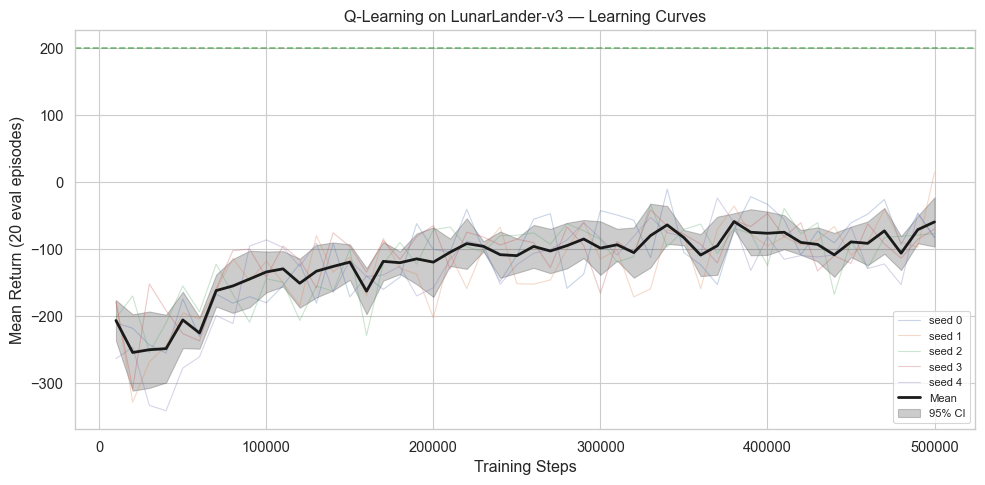

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

# Per-seed curves
for seed, res in seed_results.items():
    steps, means, stds = zip(*res['history']['eval_returns'])
    ax.plot(steps, means, alpha=0.3, linewidth=0.8, label=f'seed {seed}')

# Aggregate mean ± SEM
# Align on common timesteps
all_steps = sorted(set(
    s for res in seed_results.values()
    for s, _, _ in res['history']['eval_returns']
))
step_means = []
step_sems = []
for step in all_steps:
    vals = []
    for res in seed_results.values():
        for s, m, _ in res['history']['eval_returns']:
            if s == step:
                vals.append(m)
                break
    if vals:
        step_means.append(np.mean(vals))
        step_sems.append(np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0)

ax.plot(all_steps, step_means, 'k-', linewidth=2, label='Mean')
ax.fill_between(
    all_steps,
    np.array(step_means) - 1.96 * np.array(step_sems),
    np.array(step_means) + 1.96 * np.array(step_sems),
    alpha=0.2, color='black', label='95% CI'
)

ax.set_xlabel('Training Steps')
ax.set_ylabel('Mean Return (20 eval episodes)')
ax.set_title('Q-Learning on LunarLander-v3 — Learning Curves')
ax.legend(loc='lower right', fontsize=8)
ax.axhline(y=200, color='green', linestyle='--', alpha=0.5, label='Solved threshold')
plt.tight_layout()
plt.savefig(str(LOGS_ROOT / 'q_learning_learning_curves.png'), dpi=150)
plt.show()

## 8.5 Exploration diagnostics

*Track ε decay and state-space coverage over training.  The coverage percentage tells us what fraction of the 4M-state discretisation the agent actually visits — expect <1%.*

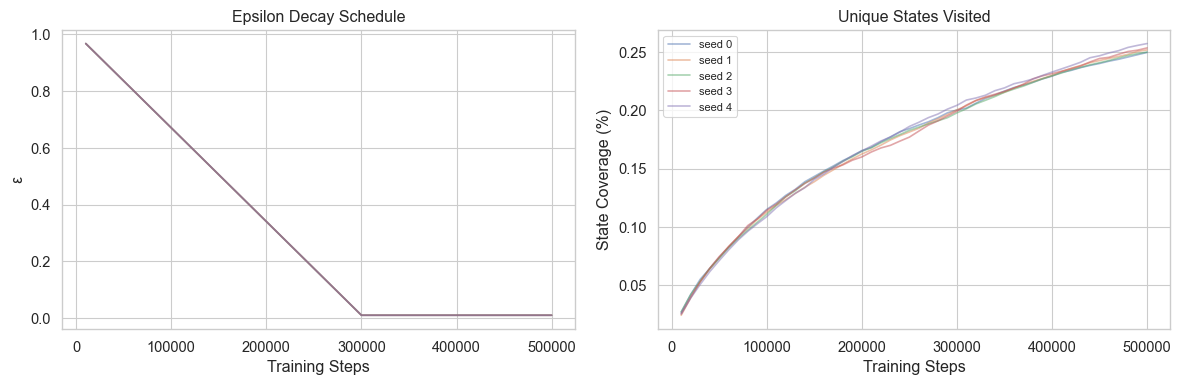

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Epsilon decay
for seed, res in seed_results.items():
    steps, eps = zip(*res['history']['epsilon_log'])
    ax1.plot(steps, eps, alpha=0.5)
ax1.set_xlabel('Training Steps')
ax1.set_ylabel('ε')
ax1.set_title('Epsilon Decay Schedule')

# State coverage
for seed, res in seed_results.items():
    steps, visited = zip(*res['history']['visited_states'])
    pct = [100 * v / discretizer.n_states for v in visited]
    ax2.plot(steps, pct, alpha=0.5, label=f'seed {seed}')
ax2.set_xlabel('Training Steps')
ax2.set_ylabel('State Coverage (%)')
ax2.set_title('Unique States Visited')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(str(LOGS_ROOT / 'q_learning_exploration.png'), dpi=150)
plt.show()

## 8.6 Fault evaluation

*Evaluate Q-learning under the same step-fault (t=200, main-engine drop) used for PPO and PPO_DR.  Since Q-learning acts in the same discrete Discrete(4) space as PPO, the fault wrapper rewrites action 2 (main engine) to action 0 (no-op).*

In [6]:
fault_results = {}

for seed, res in seed_results.items():
    agent = res['agent']
    eval_env = gym.make(ENV_ID)
    eval_env.reset(seed=seed + 9999)

    sig = evaluate_with_signals(
        agent=agent,
        env=eval_env,
        n_episodes=50,
        fault_step=200,
        fault_gain=0.5,
        discrete_drop_action=2,
    )
    fault_results[seed] = sig
    mean_r = np.mean(sig['episode_returns'])
    print(f'Seed {seed} under fault: mean={mean_r:+.2f}')
    eval_env.close()

fault_means = [np.mean(fr['episode_returns']) for fr in fault_results.values()]
print(f'\nAggregate fault mean: {np.mean(fault_means):+.2f} '
      f'± {np.std(fault_means, ddof=1):.2f}')

# Compare to nominal
nom_means = [r['mean_return'] for r in seed_results.values()]
print(f'Nominal mean:        {np.mean(nom_means):+.2f}')
print(f'Degradation:         {np.mean(fault_means) - np.mean(nom_means):+.2f}')

Seed 0 under fault: mean=-91.11
Seed 1 under fault: mean=-69.27
Seed 2 under fault: mean=-87.33
Seed 3 under fault: mean=-69.95
Seed 4 under fault: mean=-102.37

Aggregate fault mean: -84.01 ± 14.26
Nominal mean:        -63.87
Degradation:         -20.14


## 8.7 Discussion

### 8.7.1 Expected Performance Gap

Q-learning's coarse 10-bin discretisation creates a fundamental information bottleneck.  Two physically distinct states — say $(x=0.12, v_y=-1.95)$ and $(x=0.18, v_y=-2.05)$ — may map to the same bin, forcing the agent to choose a single action for both.  Deep-RL agents (PPO, SAC) with continuous observations can distinguish them.  The performance gap is the *price of interpretability*: we can directly read every Q(s,a) value from the table, at the cost of task performance.

### 8.7.2 State Coverage

The coverage percentage quantifies the *curse of dimensionality* for tabular methods.  With 4M possible states and 500k training steps, the agent visits <1% of the state space.  Most entries in the Q-table remain at their initial value of zero.  This means:

- **Generalisation is nil.** States not visited during training have Q=0 for all actions — the agent acts randomly in unseen regions.
- **Robustness is impossible.** Domain randomization cannot work with a table — the agent needs to visit each state under each physics variant, which is combinatorially infeasible.

This observation directly supports the thesis argument for function approximation in fault-tolerant control.

### 8.7.3 Implications for self-detection

The Q-value time series recorded under fault in Section 8.6 is analysed with the full detection protocol in **NB09**, and the tabular agent re-enters the study in **NB18**.  The question posed here was: does $V(s) = \max_a Q(s,a)$ show a usable shift at fault onset in the tabular case?

**Answer, from the later notebooks: no — and the reason is instructive.**  The tabular agent's own Bellman residual is crippled by *state aliasing*: with a 10-bin discretisation, the pre-fault and post-fault states frequently fall in the same bin, so the table cannot represent the dynamical shift that a detector would need to see.  NB18 reports no usable internal-signal detection score for the tabular agent, while an **external forward model** monitoring the same episodes reaches $J \approx 0.56$.

This resolves the question in its stronger form: self-detection from *internal* signals is **not** simply a structural property of value-based RL — it requires representational capacity the table lacks.  The dynamical evidence of the fault is still present in the environment (the forward model finds it); what the table lacks is the resolution to encode it.  The tabular baseline therefore bounds the study from below on **both** axes — task performance *and* self-monitoring — which is precisely the role it was added to play.

### 8.7.4 Defence of the untuned tabular baseline

An examiner may reasonably ask whether the tabular agent's poor showing reflects tabular Q-learning itself or merely an under-tuned implementation.  The distinction matters, because two separate claims rest on this baseline, and they are defensible to different degrees.

**On task performance, the honest position is that the baseline is deliberately untuned and is not offered as a competitive result.**  Hyperparameters follow `configs/q_learning_lunarlander.yaml` unmodified, with the same n = 5 seed convention as every other agent, so no selective tuning distorts the cross-algorithm comparison in either direction.  Tabular methods are not expected to solve LunarLander without some form of function approximation: the standard remedy is tile coding or another coarse-coding scheme that supplies generalisation across nearby states, and adopting one would change the agent's representational class rather than its hyperparameters.  Uniform binning at 10 bins per dimension was chosen precisely because it is the *simplest possible* value representation, which is what makes it informative as a floor.  A tuned tabular agent would raise the floor without changing what the floor demonstrates.

**On self-monitoring, the claim is stronger and does not depend on tuning at all, because NB18 supplies a within-agent control.**  The forward-model monitor in NB18 is trained on the tabular agent's *own* nominal rollouts and evaluated on the *same* fault episodes, under the identical per-seed nominal-relative detection protocol.  Only the monitor differs.  That monitor reaches $J \approx 0.56$ where the agent's own Bellman residual yields no usable score.  The dynamical evidence of the fault is therefore demonstrably present in the data the agent generated; what is missing is the resolution to encode it in a lookup table whose bins straddle the pre- and post-fault states.  Undertraining cannot explain this contrast, since both monitors observe the same episodes produced by the same policy.

**Scope of the resulting claim.**  What this notebook licenses is not "tabular RL cannot detect faults" but the narrower and better-supported statement that *self-detection from internal signals requires representational capacity that a coarsely discretised table does not provide, even when the fault is plainly recoverable from the same trajectories by an external model*.  Establishing whether a tile-coded or adaptively-binned tabular agent recovers internal detectability is a well-posed and inexpensive follow-up, and is recorded as future work rather than claimed here.

---

### Bugs encountered during Q-learning implementation

| # | Symptom | Diagnosis | Fix |
|---|---------|-----------|-----|
| QL-1 | Memory explosion with n_bins=20 | $20^6 \times 4 \times 4 = 10.2$B entries | Reduced to n_bins=10 (4M states); sparse dict storage |
| QL-2 | Agent scores ~-200 across all training | Q-table initialised to random values | Changed to zero-initialisation; random init biases early actions |

*These bugs are preserved for the thesis Lessons Learned appendix.*